# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

**Part 1**

The model is linear in the parameters (coefficients). This means that for a 1 unit increase of a explanatory variable (whether it is transformed or squared...etc),the predicted output will change linearly by the value of the coefficient

**Part 2**

The coefficient for a dummy variable is the difference in predicted outcome between that dummy and whichever observation type was excluded from the model as a coefficient to avoid perfect multicolinearity

**Part 3**

It technically can be used to classifiy in specific scenarios where there are ordinal categories by setting thresholds in predicited values for each category, however it generally performs worse tan logistic regression, which is designed to classify

**Part 4**

Some signs that the model is overfitting is high training R^2, but low testing R^2, high RMSE in testing, overly complex models that match the shape of training distribution, and high standard errors of coefficients.

**Part 5**

Multicolinearity occurs when explanatory variables are highly correlated with each other. When using 2SLS, you regress one explanatory variable on the other, then regress the dependent variable on these fitted values. The issue of multicolinearity occurs becuase the model is not able to isolate the effect of which explanatory variable is affecting the dependent variable, since their is significant overlap between both explanatory variables.

**Part 6**

You can incorporate non-linear relationships into a linear model by transforming the data (explanatory or dependent variables), or by adding polynomial or interaction terms.

**Part 7**

The intercept is the predicted dependent value when all explanatory variables included are equal to 0. A slope coefficient ($\beta$$_j$) for a variable (x$_j$) shows the by how many units of y the predicted value of y changes by a 1-unit increase in the value of x$_j$. For a dummy variable (x$_j$), the coefficient ($\beta$$_j$) shows the difference in predicted outcome between that dummy and whichever observation type was excluded from the model as a coefficient to avoid perfect multicolinearity.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns

Price by Neighbourhood 
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64

Manhattan is the most expensive

Score by Neighbourhood 
Bronx            91.654378
Brooklyn         92.363497
Manhattan        91.801496
Queens           91.549057
Staten Island    90.843750
Name: Review Scores Rating, dtype: float64


<Axes: xlabel='Price', ylabel='Density'>

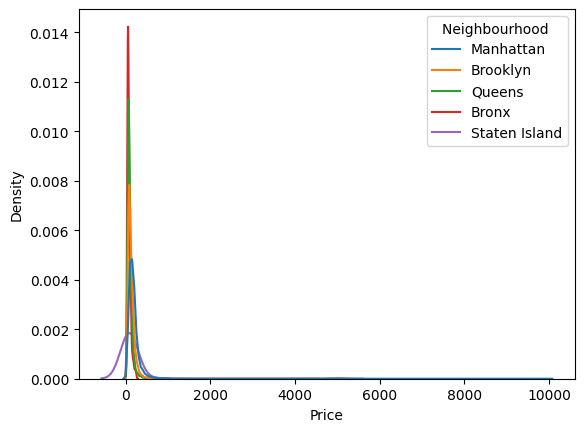

In [9]:
df = pd.read_csv('/content/Q1_clean.csv')
print(f"Price by {df.groupby('Neighbourhood ')['Price'].mean()}\n")
print("Manhattan is the most expensive\n")
print(f"Score by {df.groupby('Neighbourhood ')['Review Scores Rating'].mean()}")
sns.kdeplot(data=df, x='Price', hue='Neighbourhood ',common_norm=False)




<Axes: xlabel='Price', ylabel='Density'>

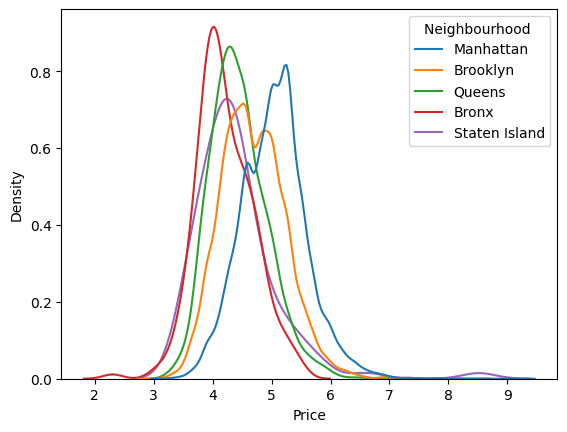

In [10]:
sns.kdeplot(data=df, x=np.log(df['Price']), hue='Neighbourhood ',common_norm=False)

In [11]:
#Part 2
from sklearn.linear_model import LinearRegression
LinearRegression(fit_intercept=False).fit(pd.get_dummies(df['Neighbourhood ']),df['Price']).coef_

#The regression coefficients are the same as the mean price for each neighbourhood.

array([ 75.2764977 , 127.74737834, 183.66428632,  96.8572327 ,
       146.16666667])

In [12]:
#Part 3
WithIntercept=LinearRegression(fit_intercept=True).fit(pd.get_dummies(df['Neighbourhood '],drop_first=True),df['Price'])
print(f'Intercept: {WithIntercept.intercept_}\n')
print(f'Coefficients: {WithIntercept.coef_}\n')
#To find the coefficients in part 2, the intercept is B1, and the rest are there respective coefficients plus the interceptsl/

Intercept: 75.27649769585331

Coefficients: [ 52.47088065 108.38778863  21.58073501  70.89016897]



In [13]:
#Part 4
from sklearn.model_selection import train_test_split
dummies = pd.get_dummies(df['Neighbourhood '],drop_first=True)
X = pd.concat([df['Review Scores Rating'],dummies],axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2, random_state= 99)
reg = LinearRegression(fit_intercept=True).fit(X_train,y_train)
print(f'R^2: {reg.score(X_test,y_test)}\n')
print(f'RMSE: {np.sqrt(np.mean((reg.predict(X_test)-y_test)**2))}\n')
print(f'Intercept: {reg.intercept_}\n')
print(f'Coefficients: {reg.coef_}\n')

#The highest priced unit is one in manhattan with rating =100
#Coefficient on Review Score: 1.00759761

R^2: 0.07244815327117138

RMSE: 121.4898314979827

Intercept: -22.126208538479176

Coefficients: [  1.00759761  57.24673179 113.1298595   26.28364219  82.07413089]



In [14]:
print(f"Price by {df.groupby('Property Type')['Price'].mean()}\n")


Price by Property Type
Apartment          153.928470
Bed & Breakfast    103.095588
Boat               153.333333
Bungalow           143.666667
Cabin              165.000000
Camper/RV           66.666667
Castle             150.000000
Chalet              99.000000
Condominium        241.229167
Dorm                65.545455
House              147.142399
Hut                 50.000000
Lighthouse          39.000000
Loft               203.571912
Other              178.928571
Townhouse          214.253012
Treehouse          167.666667
Villa              154.000000
Name: Price, dtype: float64



In [26]:
#Part 5
dummies2 = pd.get_dummies(df['Property Type'],drop_first=True)
X2 = pd.concat([df['Review Scores Rating'],dummies,dummies2],axis=1)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y,test_size=.2, random_state= 99)
reg2 = LinearRegression(fit_intercept=True).fit(X2_train,y2_train)
print(f'R^2: {reg2.score(X2_test,y2_test)}\n')
print(f'RMSE: {np.sqrt(np.mean((reg2.predict(X2_test)-y2_test)**2))}\n')
print(f'Intercept: {reg2.intercept_}\n')
print(f'Coefficients: {reg2.coef_}\n')
#The coefficient on Score Rating is 1.00689576
#The highest price you could find is a unit in staten island, property type = condiminium, &

R^2: 0.08646361073380282

RMSE: 120.56847234010944

Intercept: -36.06645268449287

Coefficients: [ 1.00689576e+00  6.46110310e+01  1.25558750e+02  3.16665223e+01
  7.46272192e+01 -3.27474485e+01  6.19545524e+01  5.62896557e+01
 -2.66453526e-14 -2.25406321e+01 -4.01818734e+01 -2.92272585e+01
  9.12847517e+01 -4.82110171e+01  3.54186499e+01 -1.34140499e+02
 -9.02341542e+01  5.99396013e+01  4.87208281e+01  3.85604783e+01
 -7.60956765e+01  3.46359272e+01]



In [43]:
#Part 6: If the coefficent on Review Score Changed after adding more variables to the model, it was likely covariated with some of those new variables, and previously the model was assinging the effects
# of these variables to Review Score since property type was not included in the o

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

              Price  Seating_Capacity   Mileage_Run
count  9.760000e+02        976.000000    976.000000
mean   7.410195e+05          5.095287  41571.195697
std    3.673234e+05          0.446224  24390.995134
min    1.880000e+05          4.000000   1117.000000
25%    4.757500e+05          5.000000  22676.750000
50%    6.665000e+05          5.000000  37570.500000
75%    8.830000e+05          5.000000  57421.250000
max    2.941000e+06          8.000000  99495.000000


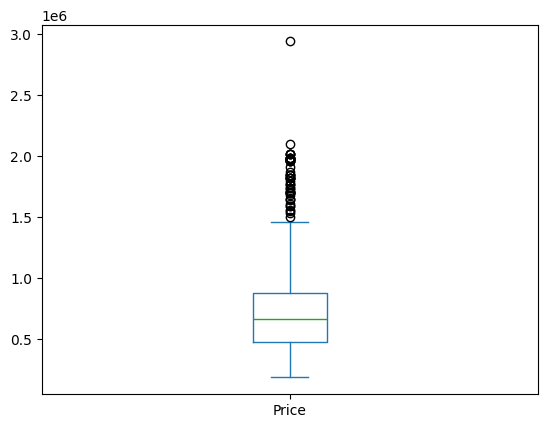

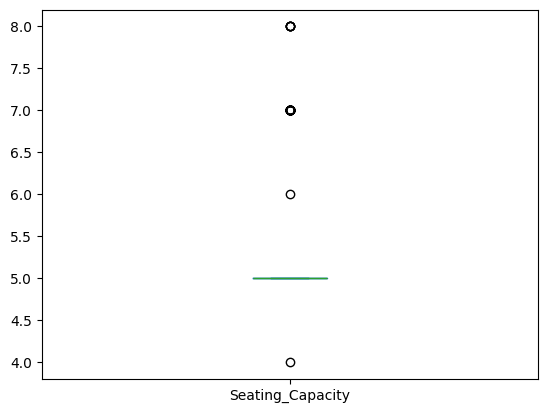

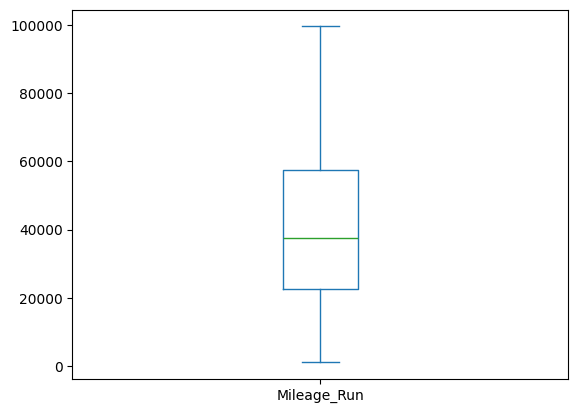

In [57]:
import matplotlib.pyplot as plt
cars = pd.read_csv('/content/cars_hw.csv')
numericals = ['Price','Seating_Capacity','Mileage_Run']
print(cars[numericals].describe())
for i in numericals:
  cars[i].plot.box()
  plt.show()


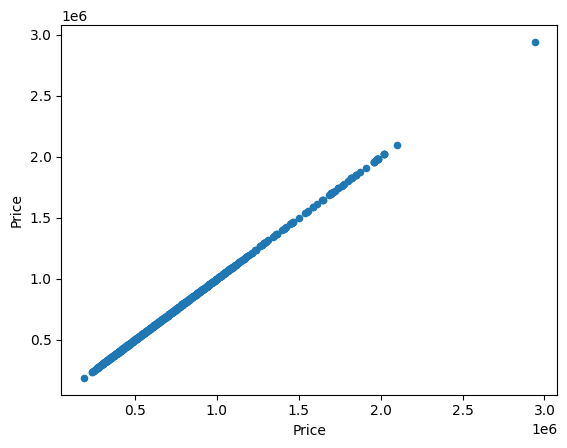

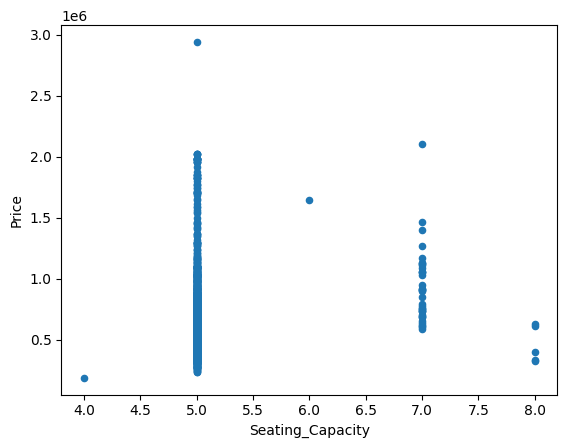

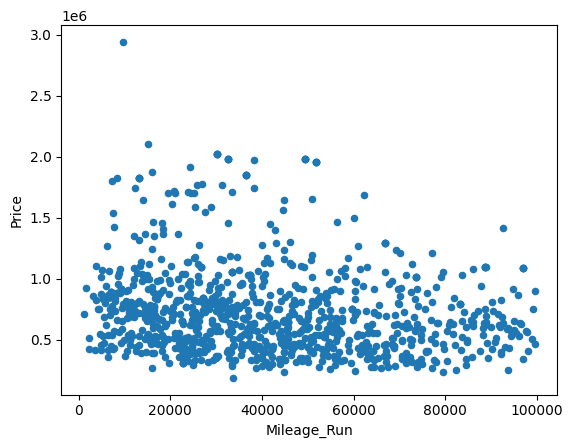

In [59]:
for i in numericals:
  cars.plot.scatter(i, 'Price')
  plt.show()

In [100]:
cars2 = cars.copy()
cars2["Price"]=np.log(cars2["Price"])
cars2.rename(columns={"Price":"Log_Price"}, inplace=True)



KeyError: 'Price'

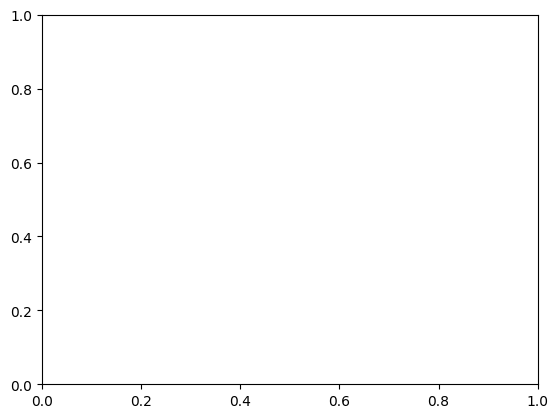

In [102]:
for i in numericals:
  cars2.plot.scatter(i, 'Log_Price')
  plt.show()

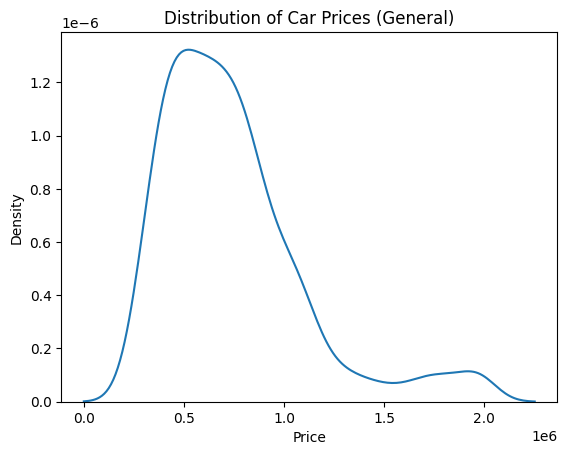

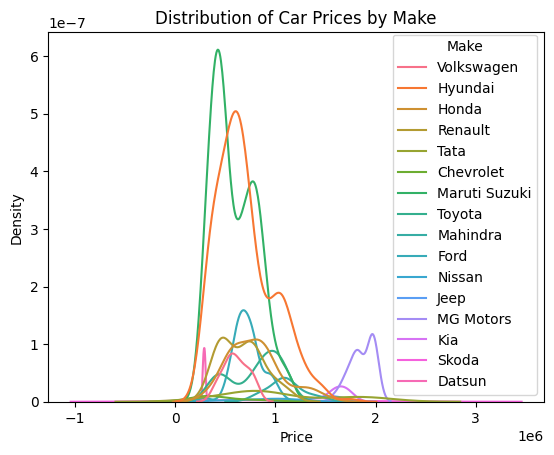

In [89]:
#Part 2
sns.kdeplot(np.exp(cars2['Price']))
plt.title("Distribution of Car Prices (General)")
plt.show()
sns.kdeplot(data = cars2, x = np.exp(cars2['Price']), hue = 'Make')
plt.title("Distribution of Car Prices by Make")
plt.show()

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.